# Risk Analytics & Exploratory Data Analysis (EDA)

**Objective:**
The primary goal of this analysis is to evaluate the risk portfolio of our insurance products by integrating multiple data facets: agent performance, customer demographics, policy details, and historical claims. 

This Exploratory Data Analysis (EDA) aims to:
1. **Assess Data Quality:** Identify and remediate missing values, duplicates, and typographical inconsistencies across all enterprise datasets.
2. **Uncover Key Drivers:** Understand the distributions of critical variables such as customer risk scores, policy coverage amounts, and claim payouts.
3. **Establish a Robust Foundation:** Standardize the data schema to facilitate advanced predictive risk modeling and strategic decision-making.

---
### Environment Setup & Data Ingestion

In [1]:
# Import necessary libraries for data manipulation and visualization.
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Safe IPython display fallback
try:
    from IPython.display import display
except ImportError:
    display = print

plt.rcParams.update({
    'figure.figsize': (12, 5),
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.titleweight': 'bold',
    'figure.facecolor': 'white',
    'axes.grid': True,
    'grid.alpha': 0.3
})
sns.set_style('whitegrid')


In [2]:
# Robust Data Ingestion with relative & absolute fallback paths
import os
import pandas as pd

def load_file(filename):
    candidate_paths = [
        filename,
        os.path.join('data', 'raw', filename),
        os.path.join('..', 'data', 'raw', filename),
        os.path.join('..', filename),
        os.path.abspath(os.path.join('..', 'data', 'raw', filename)),
        os.path.abspath(os.path.join('data', 'raw', filename))
    ]
    for p in candidate_paths:
        if os.path.exists(p):
            return pd.read_excel(p)
    raise FileNotFoundError(f'Could not find {filename}. Checked paths: {candidate_paths}')

agent_info = load_file('agentinfo.xlsx')
customer_feedback = load_file('customerfeedback.xlsx')
customer_master = load_file('customermaster.xlsx')
policy_details = load_file('policydetails.xlsx')
claim_history = load_file('claimhistory.xlsx')
print('[OK] All 5 raw datasets loaded successfully!')


[OK] All 5 raw datasets loaded successfully!


---
## 1. Agent Performance & Demographic Profiling
We begin by assessing the **Agent Information** dataset to understand the distribution of our sales force. This section focuses on fundamental data quality checks—such as missing values, data types, and cardinality—to ensure we have a robust foundation for evaluating agent-driven risk metrics.

In [3]:
# Check the dimensions (number of rows and columns) of the Agent Information dataset.

agent_info.shape

(300, 7)

In [4]:
# Display the structure of the Agent Information dataset, including column names, data types, and non-null counts.

agent_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   agent_id             300 non-null    object        
 1   region               300 non-null    object        
 2   join_date            300 non-null    datetime64[ns]
 3   total_policies_sold  300 non-null    int64         
 4   lapsed_policies      300 non-null    int64         
 5   avg_premium_sold     300 non-null    float64       
 6   fraud_association    300 non-null    int64         
dtypes: datetime64[ns](1), float64(1), int64(3), object(2)
memory usage: 16.5+ KB


In [5]:
# Find the number of unique values in each column to understand data cardinality (variety of data).

agent_info.nunique()

agent_id               300
region                   6
join_date              283
total_policies_sold    179
lapsed_policies         72
avg_premium_sold       300
fraud_association       10
dtype: int64

In [6]:
# Check for any missing values across the Agent Information dataset.

agent_info.isna().any()

agent_id               False
region                 False
join_date              False
total_policies_sold    False
lapsed_policies        False
avg_premium_sold       False
fraud_association      False
dtype: bool

In [7]:
# Review the data types of each column to ensure they are formatted correctly.

agent_info.dtypes

agent_id                       object
region                         object
join_date              datetime64[ns]
total_policies_sold             int64
lapsed_policies                 int64
avg_premium_sold              float64
fraud_association               int64
dtype: object

In [8]:
# Preview the first 5 rows of the Agent Information dataset.

agent_info.head()

,agent_id,region,join_date,total_policies_sold,lapsed_policies,avg_premium_sold,fraud_association
0,AGT5000,North,2016-02-15,196,42,37018.35,8
1,AGT5001,North,2016-09-05,189,28,48370.36,5
2,AGT5002,South,2016-06-26,66,0,10489.65,3
3,AGT5003,North-East,2016-04-23,250,3,12415.84,6
4,AGT5004,South,2022-11-16,263,69,24057.14,4


---
## 2. Customer Feedback & Temporal Alignment
Customer feedback serves as a leading indicator of policyholder satisfaction and potential churn. Here, we analyze the structure of the feedback data and sanitize temporal fields (e.g., converting dates to proper datetime objects) to enable longitudinal sentiment tracking.

In [9]:
# Check the structure and data types of the Customer Feedback dataset.

customer_feedback.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   feedback_id         1000 non-null   object
 1   customer_id         1000 non-null   object
 2   date_submitted      1000 non-null   object
 3   feedback_text       1000 non-null   object
 4   satisfaction_score  1000 non-null   int64 
 5   contacted_agent     1000 non-null   object
 6   referred_claim      1000 non-null   object
dtypes: int64(1), object(6)
memory usage: 54.8+ KB


In [10]:
# Count the number of duplicate records in the Customer Feedback dataset.

customer_feedback.duplicated().sum()

np.int64(0)

In [11]:
# Convert the 'date_submitted' column to a proper datetime format for easier time-based analysis.

customer_feedback['date_submitted']=pd.to_datetime(customer_feedback['date_submitted'])

In [12]:
# Verify the 'date_submitted' column has been updated to datetime format.

customer_feedback['date_submitted']

0     2020-08-07
1     2021-01-13
2     2022-02-16
3     2021-02-16
4     2021-04-09
         ...    
995   2021-05-10
996   2022-06-10
997   2021-07-04
998   2021-11-20
999   2023-03-20
Name: date_submitted, Length: 1000, dtype: datetime64[ns]

---
## 3. Customer Demographics & Risk Profiling
Understanding our policyholders is critical for accurate risk pricing. In this section, we analyze the distribution of core demographics including customer age, risk scores, and geographical presence. We also perform crucial data standardization (e.g., correcting gender and region typos) to rectify historical inconsistencies in the raw CRM data.

In [13]:
# Check the structure and data types of the Customer Master dataset.

customer_master.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1648 entries, 0 to 1647
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   customer_id           1648 non-null   object        
 1   full_name             1648 non-null   object        
 2   age                   1648 non-null   int64         
 3   gender                1648 non-null   object        
 4   marital_status        1648 non-null   object        
 5   occupation            1648 non-null   object        
 6   region                1648 non-null   object        
 7   smoking_status        1648 non-null   object        
 8   pre_existing_illness  1648 non-null   object        
 9   risk_score            1648 non-null   float64       
 10  date_joined           1648 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(1), int64(1), object(8)
memory usage: 141.8+ KB


In [14]:
# Count the number of duplicate records in the Customer Master dataset.

customer_master.duplicated().sum()

np.int64(0)

In [15]:
# Preview the first few rows of the Customer Master dataset.

customer_master.head()

,customer_id,full_name,age,gender,marital_status,occupation,region,smoking_status,pre_existing_illness,risk_score,date_joined
0,CUST10000,Yahvi Chander,18,Male,Single,Student,West,No,Yes,0.61,2020-02-02
1,CUST10001,Gautami Batta,39,Female,Divorced,Salaried,East,Yes,Yes,0.56,2020-04-17
2,CUST10002,Zehaan Randhawa,34,Male,Single,Student,North,Yes,No,0.48,2018-06-27
3,CUST10003,Aarnav Bhandari,50,Male,Married,Self-employed,South,Yes,No,0.47,2021-12-02
4,CUST10005,Tripti Parekh,20,Female,Single,Student,North,Yes,No,0.55,2022-10-25


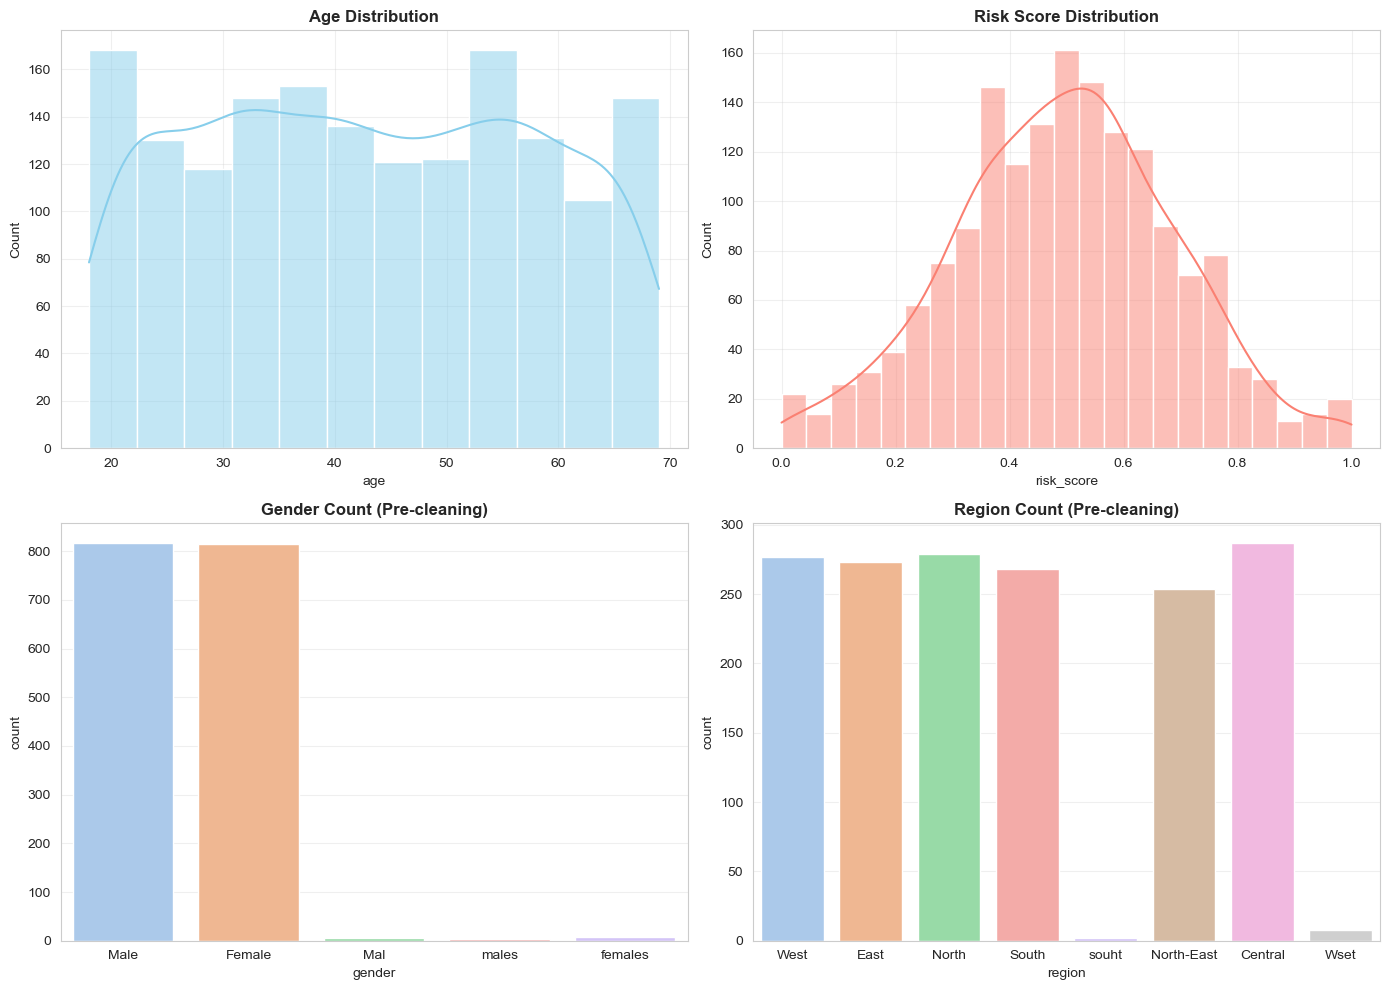

In [16]:
# Visualize the distribution of customer age, risk scores, gender, and region to understand the customer demographics.
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(customer_master['age'], kde=True, ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Age Distribution')

sns.histplot(customer_master['risk_score'], kde=True, ax=axes[0, 1], color='salmon')
axes[0, 1].set_title('Risk Score Distribution')

sns.countplot(
    data=customer_master,
    x='gender',
    hue='gender',
    palette='pastel',
    legend=False,
    ax=axes[1, 0]
)
axes[1, 0].set_title('Gender Count (Pre-cleaning)')

sns.countplot(
    data=customer_master,
    x='region',
    hue='region',
    palette='pastel',
    legend=False,
    ax=axes[1, 1]
)
axes[1, 1].set_title('Region Count (Pre-cleaning)')

plt.tight_layout()

In [17]:


customer_master['gender']

0         Male
1       Female
2         Male
3         Male
4       Female
         ...  
1643      Male
1644      Male
1645    Female
1646      Male
1647    Female
Name: gender, Length: 1648, dtype: object

In [18]:
# Standardize the 'gender' and 'region' columns by fixing typos and inconsistent capitalization.

# Dictionary mapping for cleaning text entry typos
gender_map = {
    'females': 'Female', 
    'Mal': 'Male', 
    'males': 'Male'
}

region_map = {
    'Wset': 'West',
    'souht': 'South'
}

# Apply replacements
customer_master['gender'] = customer_master['gender'].replace(gender_map)
customer_master['region'] = customer_master['region'].replace(region_map)

print("\n--- Cleaned Categorical Value Counts ---")
for col in ['gender', 'region']:
    print(f"\n{col}:")
    print(customer_master[col].value_counts())


--- Cleaned Categorical Value Counts ---

gender:
gender
Male      826
Female    822
Name: count, dtype: int64

region:
region
Central       287
West          285
North         279
East          273
South         270
North-East    254
Name: count, dtype: int64


---
## 4. Policy Portfolio & Revenue Exposure
This segment delves into our core product portfolio, examining the distribution of coverage amounts and annual premiums. Crucially, we validate the logical consistency of policy lifecycles (e.g., ensuring start dates precede end dates) and standardize categorical product types to evaluate our total exposure and revenue streams accurately.

In [19]:
# Examine the structure and data types of the Policy Details dataset.

policy_details.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2828 entries, 0 to 2827
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   policy_id          2828 non-null   object        
 1   customer_id        2828 non-null   object        
 2   product_type       2828 non-null   object        
 3   coverage_amount    2828 non-null   float64       
 4   annual_premium     2828 non-null   float64       
 5   policy_start_date  2828 non-null   datetime64[ns]
 6   policy_end_date    2828 non-null   datetime64[ns]
 7   agent_id           2828 non-null   object        
 8   status             2828 non-null   object        
dtypes: datetime64[ns](2), float64(2), object(5)
memory usage: 199.0+ KB


In [20]:
# Display the Policy Details dataset.

policy_details

,policy_id,customer_id,product_type,coverage_amount,annual_premium,policy_start_date,policy_end_date,agent_id,status
0,POL50001,CUST10833,Property,169869.71,27193.94,2021-07-25,2022-10-25,AGT5238,Active
1,POL50002,CUST11786,Health,546514.84,19603.44,2022-09-19,2024-04-29,AGT5008,Cancelled
2,POL50003,CUST10501,Property,944249.15,36274.58,2022-12-08,2025-04-23,AGT5118,Cancelled
3,POL50004,CUST10349,Property,209475.32,23091.58,2024-04-09,2024-07-20,AGT5090,Active
4,POL50005,CUST12296,Term,887938.35,10458.22,2022-10-08,2024-12-12,AGT5050,Lapsed
...,...,...,...,...,...,...,...,...,...
2823,POL53991,CUST10002,Property,300039.56,33337.52,2022-08-26,2023-05-26,AGT5262,Lapsed
2824,POL53994,CUST12172,Term,329263.38,13782.59,2023-11-10,2025-07-01,AGT5276,Cancelled
2825,POL53996,CUST11829,Property,139846.91,15519.76,2022-10-04,2024-01-29,AGT5207,Cancelled
2826,POL53998,CUST12139,Health,165202.48,35222.07,2021-01-12,2023-02-18,AGT5213,Cancelled


In [21]:
# Identify the number of missing values in each column of the Policy Details dataset.

policy_details.isnull().sum()

policy_id            0
customer_id          0
product_type         0
coverage_amount      0
annual_premium       0
policy_start_date    0
policy_end_date      0
agent_id             0
status               0
dtype: int64

In [22]:
# Count duplicate rows in the Policy Details dataset.

policy_details.duplicated().sum()

np.int64(0)

In [23]:
# Generate summary statistics (mean, min, max, etc.) for coverage amounts and annual premiums.

policy_details[['coverage_amount', 'annual_premium']].describe()

,coverage_amount,annual_premium
count,2828.000000,2828.000000
mean,541464.360244,26685.387284
std,261479.768793,13515.052134
min,100768.840000,3013.880000
25%,307727.235000,15278.452500
50%,541089.680000,26984.825000
75%,770936.092500,38141.587500
max,999900.150000,49994.210000


In [24]:
# Check for logical errors in policy dates, specifically where the policy start date is incorrectly logged after the end date.

# Find rows where start date is greater than or equal to end date
invalid_dates_mask = policy_details['policy_start_date'] > policy_details['policy_end_date']
invalid_count = invalid_dates_mask.sum()
print(invalid_count)

0


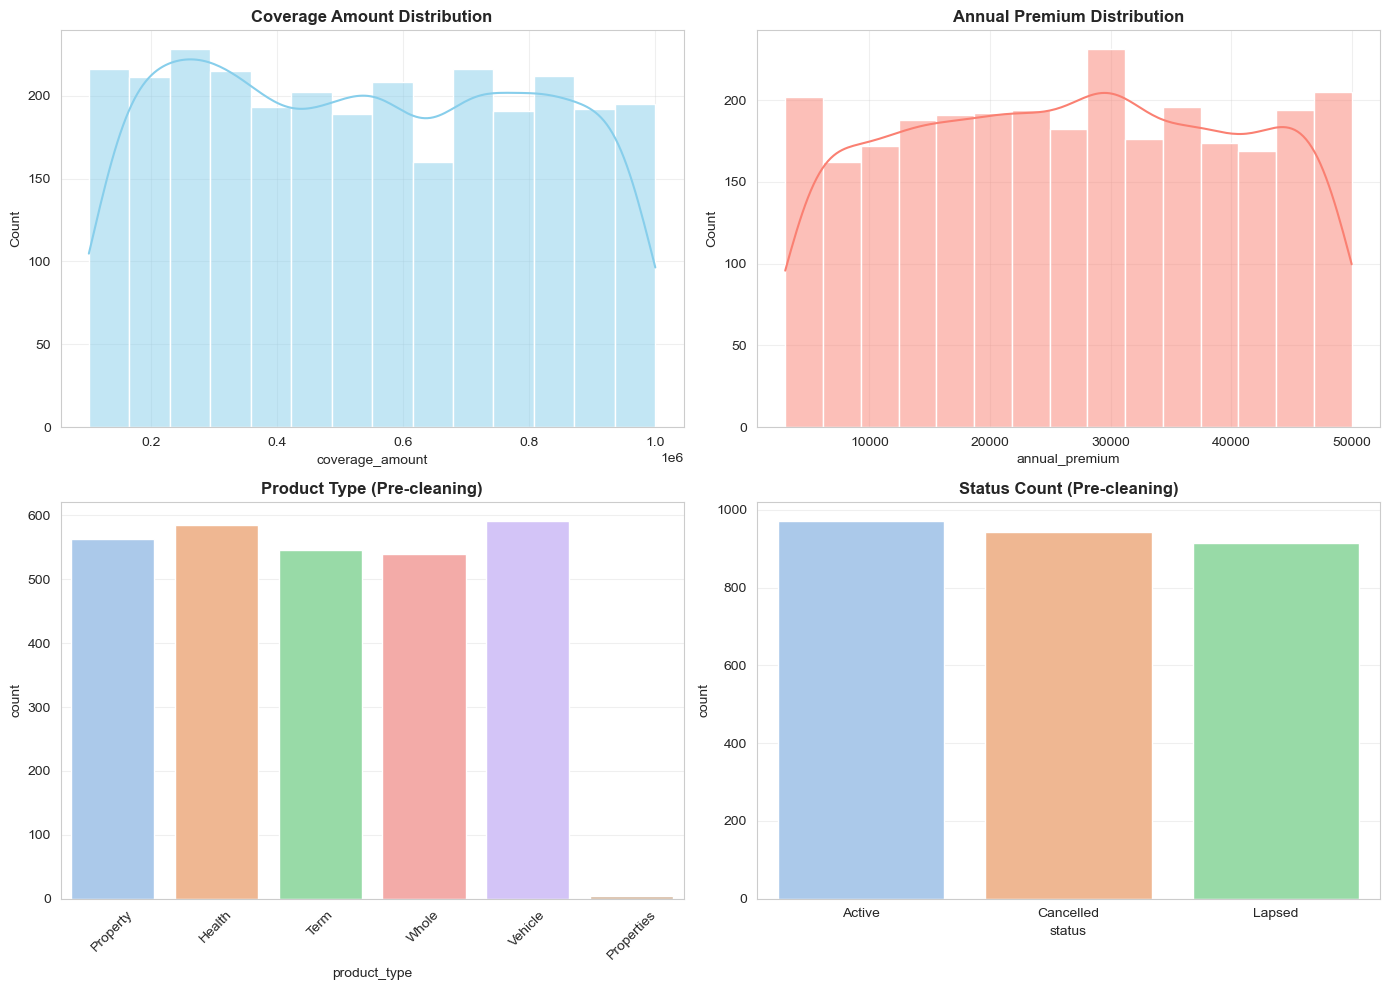

In [25]:
# Visualize the distribution of coverage amounts, annual premiums, product types, and policy statuses.

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(policy_details['coverage_amount'], kde=True, ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Coverage Amount Distribution')

sns.histplot(policy_details['annual_premium'], kde=True, ax=axes[0, 1], color='salmon')
axes[0, 1].set_title('Annual Premium Distribution')

sns.countplot(
    data=policy_details,
    x='product_type',
    hue='product_type',
    palette='pastel',
    legend=False,
    ax=axes[1, 0]
)
axes[1, 0].set_title('Product Type (Pre-cleaning)')
axes[1, 0].tick_params(axis='x', rotation=45)

sns.countplot(
    data=policy_details,
    x='status',
    hue='status',
    palette='pastel',
    legend=False,
    ax=axes[1, 1]
)
axes[1, 1].set_title('Status Count (Pre-cleaning)')

plt.tight_layout()


In [26]:
# Standardize capitalization for product types and policy statuses to ensure consistency.

# Fix capitalization inconsistencies
policy_details['product_type'] = policy_details['product_type'].str.title()
policy_details['status'] = policy_details['status'].str.title()

In [27]:
# Standardize the product type naming (e.g., replace 'Properties' with 'Property').

policy_details['product_type'] = policy_details['product_type'].replace({
    'Properties': 'Property'
})

---
## 5. Historical Claims & Loss Analysis
Claims history is the most direct indicator of risk realization. We investigate the distribution of claim amounts, flag anomalous data points (such as negative or zero claims), and clean up typographical errors in claim statuses. This thorough sanitization ensures a reliable dataset for downstream actuarial analysis and predictive risk modeling.

In [28]:
# Check the dimensions (rows and columns) of the Claim History dataset.

claim_history.shape

(1406, 8)

In [29]:
# Identify missing values in the Claim History dataset.

claim_history.isnull().sum()

claim_id           0
policy_id          0
claim_date         0
claim_amount       0
claim_status       0
claim_type         0
fraud_flag         0
days_to_process    0
dtype: int64

In [30]:
# Check for invalid claim amounts (zero or negative values).

(claim_history['claim_amount'] <= 0).sum()

np.int64(0)

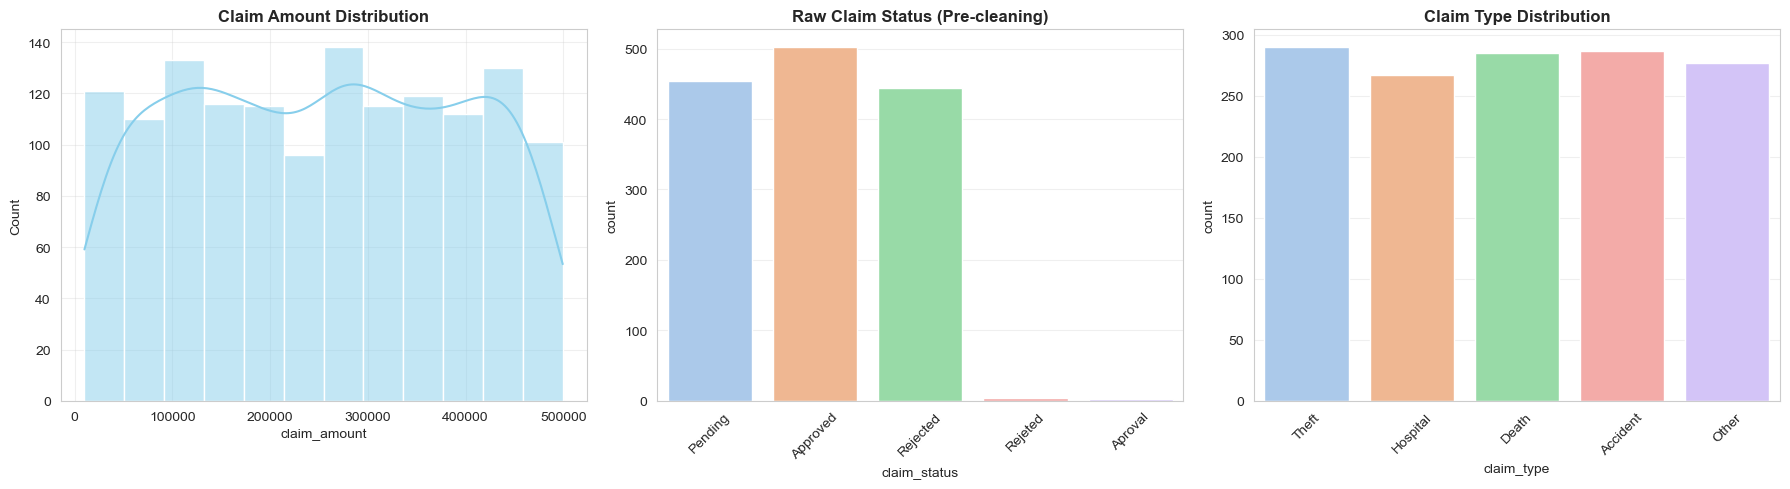

In [31]:
# Visualize the distribution of claim amounts, raw claim statuses, and claim types before data cleaning.

# Visualize the distribution of claim amounts, raw claim statuses, and claim types before data cleaning.

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot Claim Amount
sns.histplot(
    claim_history['claim_amount'],
    kde=True,
    color='skyblue',
    ax=axes[0]
)
axes[0].set_title('Claim Amount Distribution')

# Plot Claim Status (Pre-cleaning)
sns.countplot(
    data=claim_history,
    x='claim_status',
    hue='claim_status',
    palette='pastel',
    legend=False,
    ax=axes[1]
)
axes[1].set_title('Raw Claim Status (Pre-cleaning)')
axes[1].tick_params(axis='x', rotation=45)

# Plot Claim Type
sns.countplot(
    data=claim_history,
    x='claim_type',
    hue='claim_type',
    palette='pastel',
    legend=False,
    ax=axes[2]
)
axes[2].set_title('Claim Type Distribution')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [32]:
# Clean up typographical errors in the 'claim_status' column and display the corrected counts.

# 3. Data Cleaning: Fix Typos in 'claim_status'
status_corrections = {
    'Rejeted': 'Rejected',
    'Aproval': 'Approved'
}
claim_history['claim_status'] = claim_history['claim_status'].replace(status_corrections)

# 4. Post-Cleaning Summary
print("\n--- Cleaned Claim Status Counts ---")
print(claim_history['claim_status'].value_counts())


--- Cleaned Claim Status Counts ---
claim_status
Approved    504
Pending     454
Rejected    448
Name: count, dtype: int64


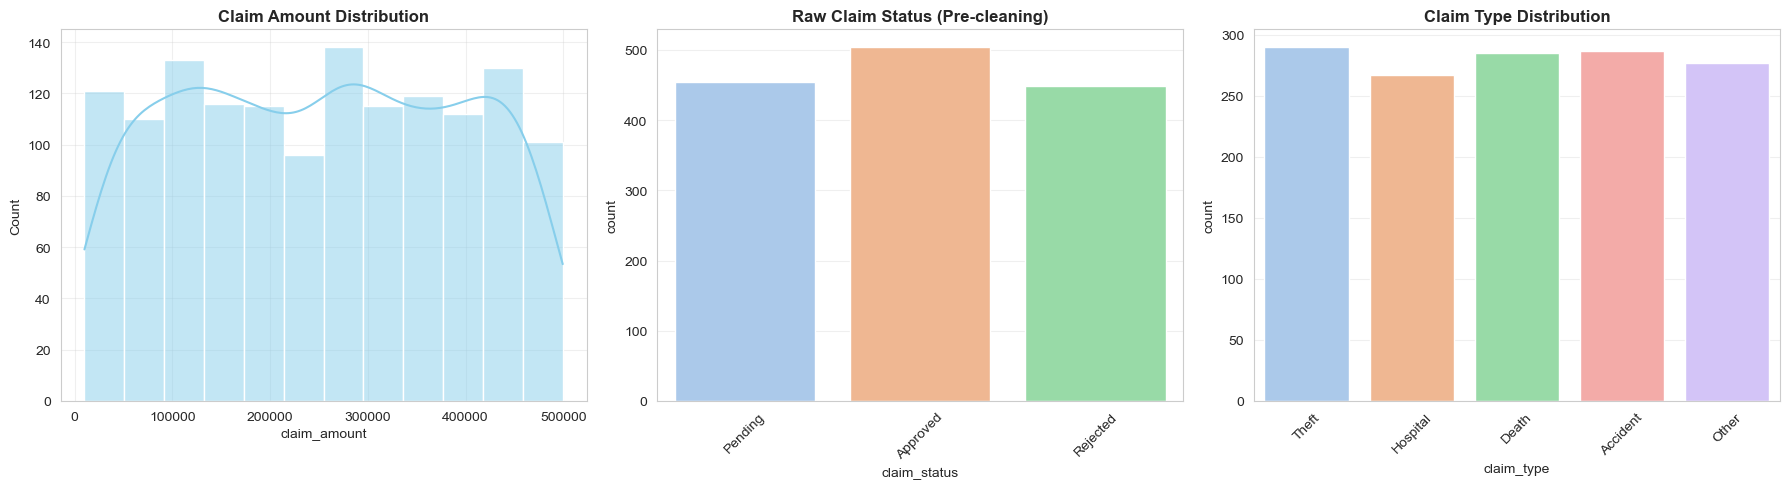

In [33]:
# Visualize the updated distribution of claim amounts, statuses, and types after cleaning.
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot Claim Amount
sns.histplot(
    claim_history['claim_amount'],
    kde=True,
    color='skyblue',
    ax=axes[0]
)
axes[0].set_title('Claim Amount Distribution')

# Plot Claim Status (This will show the typos as separate bars)
sns.countplot(
    data=claim_history,
    x='claim_status',
    hue='claim_status',
    palette='pastel',
    legend=False,
    ax=axes[1]
)
axes[1].set_title('Raw Claim Status (Pre-cleaning)')
axes[1].tick_params(axis='x', rotation=45)

# Plot Claim Type
sns.countplot(
    data=claim_history,
    x='claim_type',
    hue='claim_type',
    palette='pastel',
    legend=False,
    ax=axes[2]
)
axes[2].set_title('Claim Type Distribution')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

==========================================================================

---
## 6. Feature Engineering (Derived Columns)
To enrich our dataset for deeper analysis and predictive modeling, we engineer several derived columns:
- **Policy Duration:** The total active days for a policy (End Date - Start Date).
- **Agent Fraud Ratio:** The proportion of fraudulent associations relative to total policies sold by an agent.
- **Claims per Customer:** The historical count of claims filed by each unique customer.

In [34]:
# 1. Calculate Policy Duration in days
policy_details['policy_duration_days'] = (policy_details['policy_end_date'] - policy_details['policy_start_date']).dt.days

# 2. Calculate Agent Fraud Ratio
agent_info['agent_fraud_ratio'] = agent_info['fraud_association'] / agent_info['total_policies_sold']

# 3. Calculate Claims per Customer
# Map policy_id to customer_id
claims_with_customers = claim_history.merge(policy_details[['policy_id', 'customer_id']], on='policy_id', how='left')
# Count claims per customer
claims_per_customer = claims_with_customers.groupby('customer_id')['claim_id'].count().reset_index()
claims_per_customer.rename(columns={'claim_id': 'claims_count'}, inplace=True)
# Merge back to customer_master
customer_master = customer_master.merge(claims_per_customer, on='customer_id', how='left')
customer_master['claims_count'] = customer_master['claims_count'].fillna(0.0)

# Display a preview of the derived columns
print("Agent Fraud Ratio (Top 5):")
display(agent_info[['agent_id', 'agent_fraud_ratio']].head())

print("\nClaims Count per Customer (Top 5):")
display(customer_master[['customer_id', 'claims_count']].head())


Agent Fraud Ratio (Top 5):


,agent_id,agent_fraud_ratio
0,AGT5000,0.040816
1,AGT5001,0.026455
2,AGT5002,0.045455
3,AGT5003,0.024000
4,AGT5004,0.015209



Claims Count per Customer (Top 5):


,customer_id,claims_count
0,CUST10000,1.0
1,CUST10001,0.0
2,CUST10002,1.0
3,CUST10003,0.0
4,CUST10005,1.0


---
## 7. Advanced Exploratory Data Analysis (EDA)
In this section, we expand our EDA using Pandas, Matplotlib, and Seaborn to:
- Visualize temporal trends, specifically monthly claim volumes.
- Use heatmaps and boxplots to detect regional and product-level patterns.
- Summarize key metrics using grouped statistics (mean, median, standard deviation).

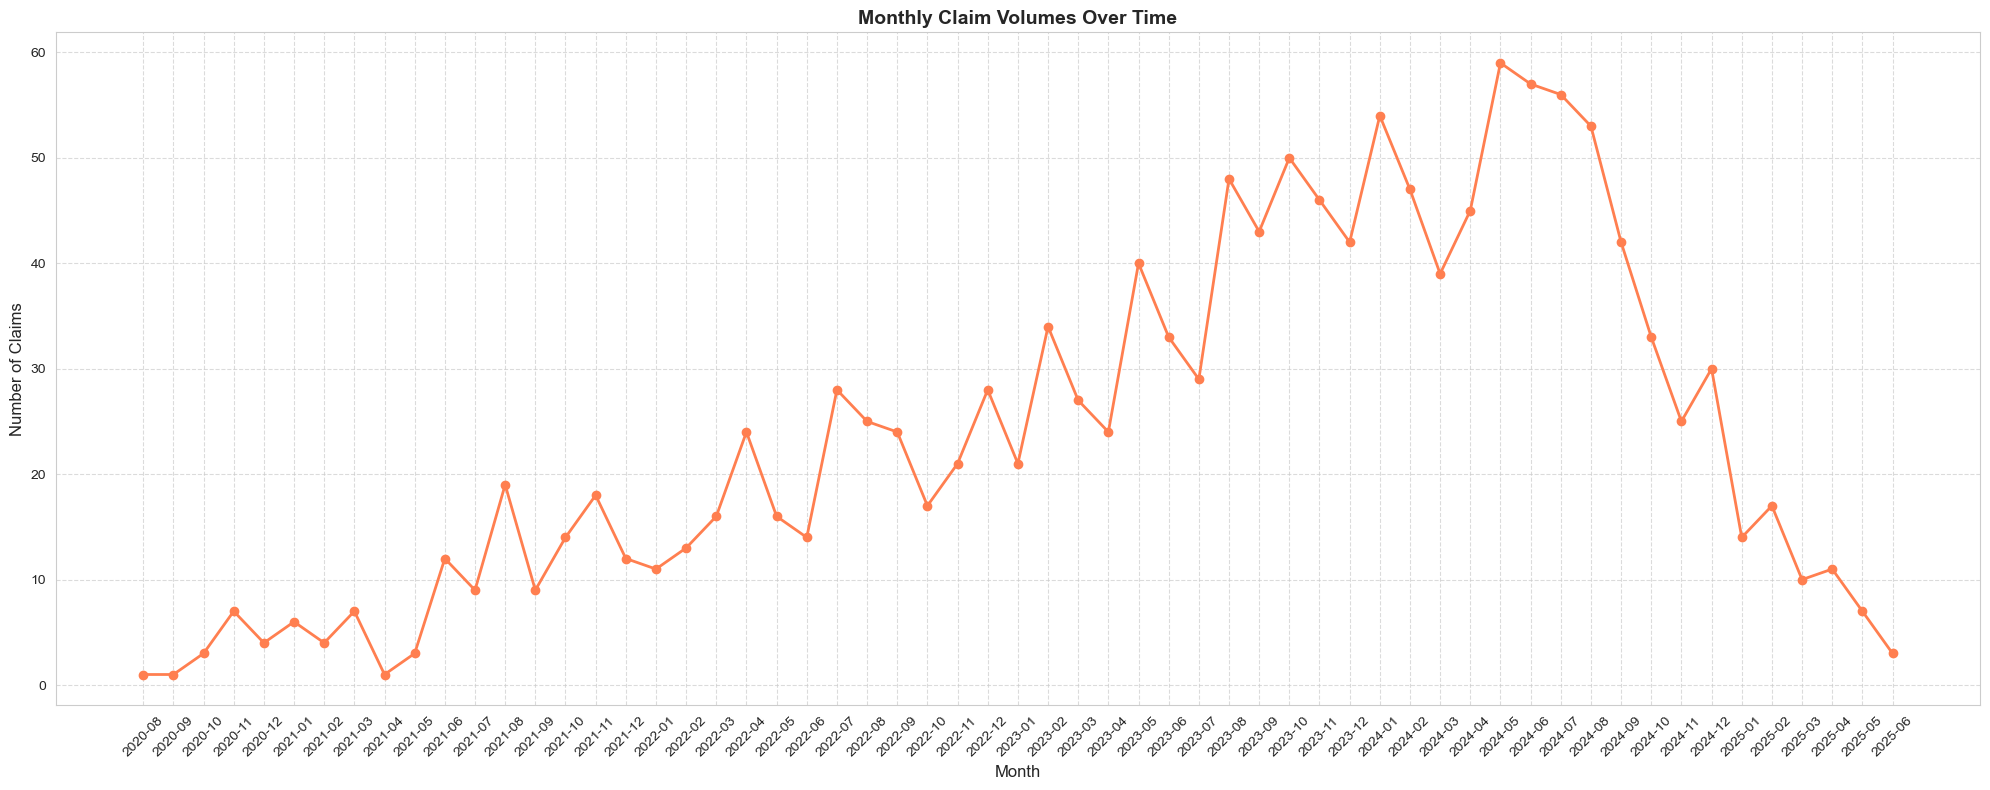

In [35]:
# Visualize monthly claim volumes over time
# Extract year-month from claim_date for grouping
claim_history['claim_month'] = claim_history['claim_date'].dt.to_period('M')
monthly_claims = claim_history.groupby('claim_month').size()

plt.figure(figsize=(20, 8))
# Convert index to string for plotting to avoid period index issues in some matplotlib versions
monthly_claims.index = monthly_claims.index.astype(str)
plt.plot(monthly_claims.index, monthly_claims.values, marker='o', color='coral', linewidth=2)
plt.title('Monthly Claim Volumes Over Time', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Number of Claims', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


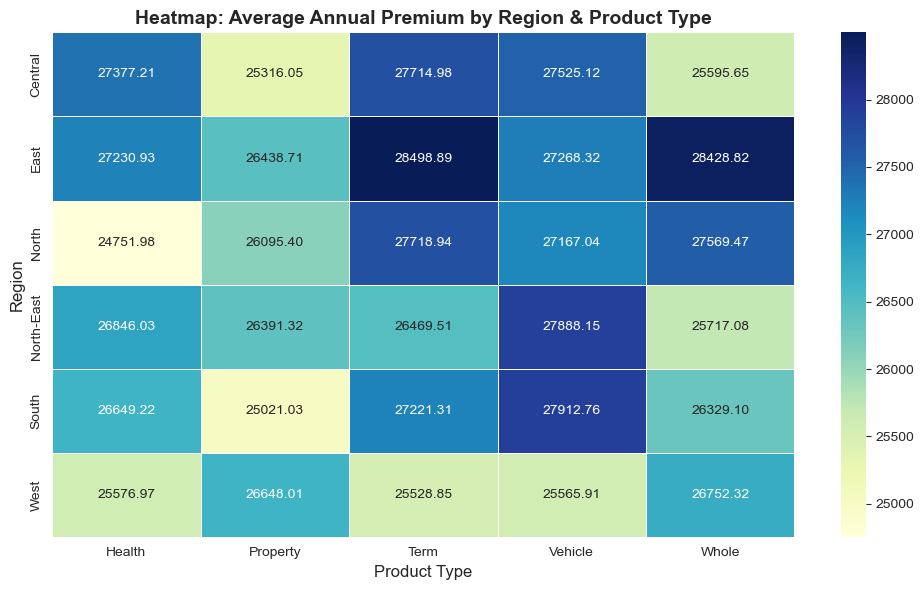

In [36]:
# Merge policy details with customer master to analyze regional and product-level data
policy_customer_df = policy_details.merge(customer_master[['customer_id', 'region']], on='customer_id', how='inner')

# Heatmap: Average Annual Premium by Region and Product Type
pivot_premium = policy_customer_df.pivot_table(
    values='annual_premium', 
    index='region', 
    columns='product_type', 
    aggfunc='mean'
)

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_premium, annot=True, fmt=".2f", cmap="YlGnBu", linewidths=.5)
plt.title('Heatmap: Average Annual Premium by Region & Product Type', fontsize=14)
plt.ylabel('Region', fontsize=12)
plt.xlabel('Product Type', fontsize=12)
plt.tight_layout()
plt.show()


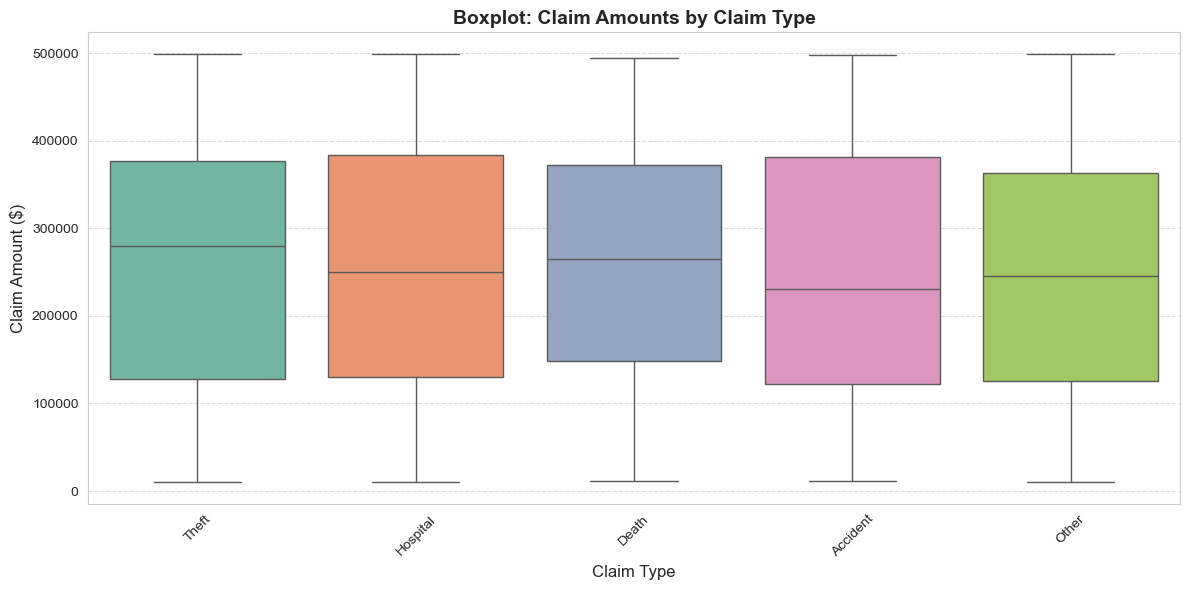

In [37]:
# Boxplot: Claim Amounts by Claim Type
plt.figure(figsize=(12, 6))
sns.boxplot(data=claim_history, x='claim_type', y='claim_amount', hue='claim_type', legend=False, palette='Set2')
plt.title('Boxplot: Claim Amounts by Claim Type', fontsize=14)
plt.xlabel('Claim Type', fontsize=12)
plt.ylabel('Claim Amount ($)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [38]:
# Summarize metrics using grouped statistics (mean, median, standard deviation)
# Analyzing Annual Premium by Product Type
grouped_stats = policy_customer_df.groupby('product_type')['annual_premium'].agg(['mean', 'median', 'std']).reset_index()

print("Annual Premium Statistics by Product Type:")
display(grouped_stats)


Annual Premium Statistics by Product Type:


,product_type,mean,median,std
0,Health,26422.001949,27364.10,13355.015564
1,Property,25978.663175,25474.33,13430.649605
2,Term,27137.827927,27414.18,13315.357875
3,Vehicle,27191.550135,27393.21,13734.688428
4,Whole,26702.184685,26952.48,13741.431629


---
## 8. Statistical Analysis & Hypothesis Testing
In this section, we apply rigorous statistical testing to validate key business hypotheses. By leveraging `scipy.stats` and `statsmodels`, we move beyond descriptive statistics to assess the significance of relationships within the data.


In [39]:
import scipy.stats as stats
import numpy as np

# Merge datasets to consolidate features for statistical testing
# Link claims to policy and then to customer
claims_policy = claim_history.merge(policy_details, on='policy_id', how='inner')
claims_full = claims_policy.merge(customer_master, on='customer_id', how='inner')

# Drop missing values in the key columns we intend to test to ensure valid statistical tests
test_data = claims_full.dropna(subset=['claim_amount', 'smoking_status', 'region', 'claim_status', 'claim_type', 'risk_score'])
print(f"Data shape for statistical testing: {test_data.shape}")


Data shape for statistical testing: (1406, 29)


### 8.1 T-Test: Claim Amounts by Smoking Status
**Hypothesis:** Smokers tend to have higher average claim amounts compared to non-smokers.
- **Null Hypothesis (H0):** There is no significant difference in the average claim amount between smokers and non-smokers.
- **Alternative Hypothesis (H1):** There is a statistically significant difference in the average claim amount.

*Assumptions & Limitations:* This assumes independent samples, approximately normal distribution of claim amounts within groups (or sufficiently large sample size for Central Limit Theorem), and we use Welch's t-test which does not assume equal population variances.


T-statistic: 1.8840
P-value: 5.9774e-02
95% Confidence Interval for Difference in Means: (-570.09, 28834.70)


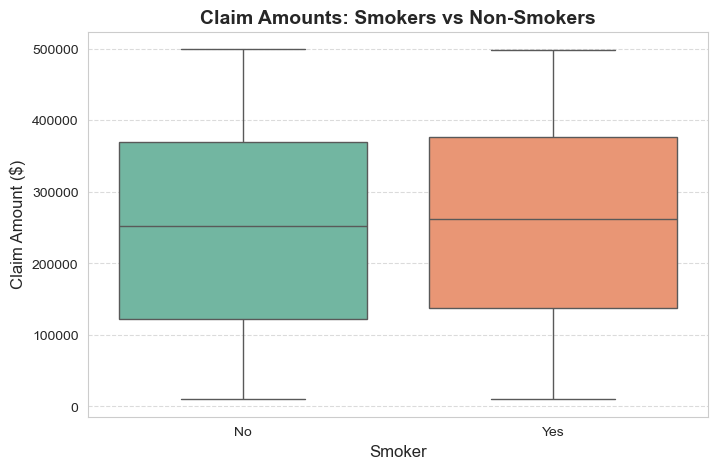

Conclusion: Fail to reject the Null Hypothesis. There is no statistically significant difference in claim amounts between smokers and non-smokers.


In [40]:
# Separate claim amounts based on smoking status
smokers = test_data[test_data['smoking_status'] == 'Yes']['claim_amount']
non_smokers = test_data[test_data['smoking_status'] == 'No']['claim_amount']

# Perform Independent 2-Sample T-test (Welch's t-test)
t_stat, p_value = stats.ttest_ind(smokers, non_smokers, equal_var=False)

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4e}")

# Confidence Interval (95%)
mean_diff = smokers.mean() - non_smokers.mean()
# Approximate CI for unequal variances
se_diff = np.sqrt(smokers.var(ddof=1)/len(smokers) + non_smokers.var(ddof=1)/len(non_smokers))
ci_lower = mean_diff - 1.96 * se_diff
ci_upper = mean_diff + 1.96 * se_diff
print(f"95% Confidence Interval for Difference in Means: ({ci_lower:.2f}, {ci_upper:.2f})")

# Visualization
plt.figure(figsize=(8, 5))
sns.boxplot(x='smoking_status', y='claim_amount', data=test_data, hue='smoking_status', palette='Set2', legend=False)
plt.title('Claim Amounts: Smokers vs Non-Smokers', fontsize=14)
plt.ylabel('Claim Amount ($)', fontsize=12)
plt.xlabel('Smoker', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Interpretation
if p_value < 0.05:
    print("Conclusion: Reject the Null Hypothesis. There is a statistically significant difference in claim amounts between smokers and non-smokers.")
else:
    print("Conclusion: Fail to reject the Null Hypothesis. There is no statistically significant difference in claim amounts between smokers and non-smokers.")


### 8.2 ANOVA: Claim Variability Across Regions
**Hypothesis:** Regional differences influence the magnitude of claim amounts.
- **Null Hypothesis (H0):** The mean claim amounts are equal across all regions.
- **Alternative Hypothesis (H1):** At least one region has a significantly different mean claim amount.

*Assumptions & Limitations:* ANOVA assumes normality of residuals, homogeneity of variance across groups, and independent observations. If variances are drastically unequal or distributions highly skewed, a non-parametric alternative like Kruskal-Wallis might be more robust.


F-statistic: 0.7634
P-value: 5.7624e-01


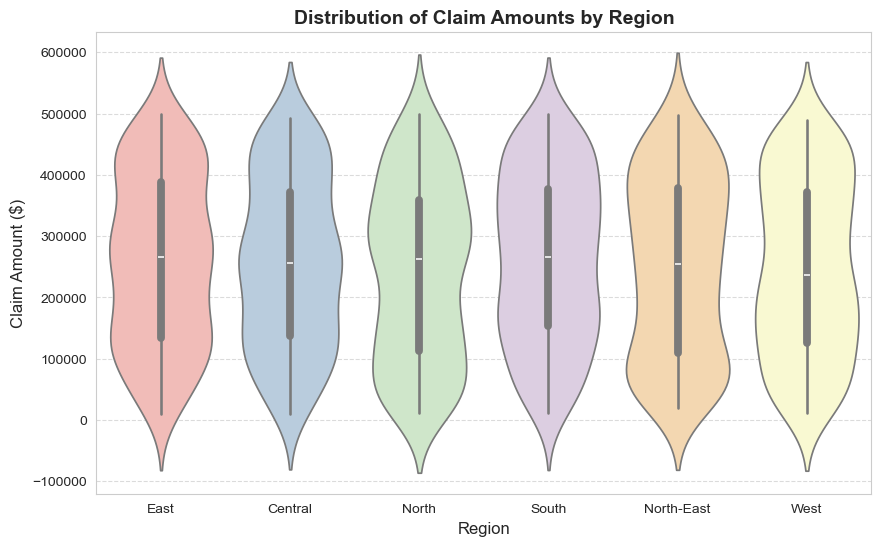

Conclusion: Fail to reject the Null Hypothesis. There is no significant regional variation in claim amounts.


In [41]:
# Extract claim amounts for each region
regions = [group['claim_amount'].values for name, group in test_data.groupby('region')]

# Perform One-Way ANOVA using scipy.stats
f_stat, p_val_anova = stats.f_oneway(*regions)

print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_val_anova:.4e}")

# Visualization
plt.figure(figsize=(10, 6))
sns.violinplot(x='region', y='claim_amount', data=test_data, hue='region', palette='Pastel1', legend=False)
plt.title('Distribution of Claim Amounts by Region', fontsize=14)
plt.ylabel('Claim Amount ($)', fontsize=12)
plt.xlabel('Region', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

if p_val_anova < 0.05:
    print("Conclusion: Reject the Null Hypothesis. Claim amounts vary significantly across different regions.")
else:
    print("Conclusion: Fail to reject the Null Hypothesis. There is no significant regional variation in claim amounts.")


### 8.3 Chi-Square Test: Claim Status vs Claim Type
**Hypothesis:** The likelihood of a claim being approved or rejected depends on the type of claim filed (e.g., auto vs. health).
- **Null Hypothesis (H0):** Claim Status and Claim Type are independent.
- **Alternative Hypothesis (H1):** There is a statistically significant association between Claim Status and Claim Type.

*Assumptions & Limitations:* Assumes that the expected frequency count for each cell in the contingency table is at least 5. If counts are too low, Fisher's Exact Test is preferred.


Contingency Table:


claim_type,Accident,Death,Hospital,Other,Theft
claim_status,,,,,
Approved,111,105,94,91,103
Pending,97,81,91,93,92
Rejected,79,99,82,93,95


Chi-Square Statistic: 6.2826
P-value: 6.1561e-01
Degrees of Freedom: 8


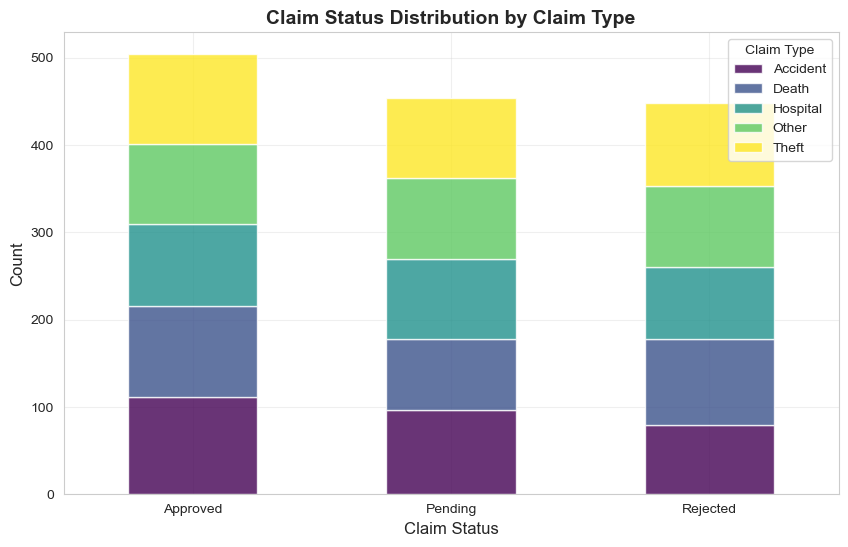

Conclusion: Fail to reject the Null Hypothesis. Claim Status and Claim Type are independent.


In [42]:
# Create contingency table
contingency_table = pd.crosstab(test_data['claim_status'], test_data['claim_type'])
print("Contingency Table:")
display(contingency_table)

# Perform Chi-Square Test
chi2, p_val_chi, dof, expected = stats.chi2_contingency(contingency_table)

print(f"Chi-Square Statistic: {chi2:.4f}")
print(f"P-value: {p_val_chi:.4e}")
print(f"Degrees of Freedom: {dof}")

# Visualization
contingency_table.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='viridis', alpha=0.8)
plt.title('Claim Status Distribution by Claim Type', fontsize=14)
plt.ylabel('Count', fontsize=12)
plt.xlabel('Claim Status', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Claim Type')
plt.show()

if p_val_chi < 0.05:
    print("Conclusion: Reject the Null Hypothesis. There is a statistically significant association between Claim Status and Claim Type.")
else:
    print("Conclusion: Fail to reject the Null Hypothesis. Claim Status and Claim Type are independent.")


### 8.4 Correlation Analysis: Risk Score vs Claim Amount
**Hypothesis:** Customers with higher assigned risk scores tend to file claims for higher amounts.
- **Null Hypothesis (H0):** There is no linear correlation between Risk Score and Claim Amount.
- **Alternative Hypothesis (H1):** There is a significant linear correlation between Risk Score and Claim Amount.

*Assumptions & Limitations:* Pearson correlation only measures *linear* relationships and is sensitive to outliers. It does not imply causation.


Pearson Correlation Coefficient: -0.0157
P-value: 5.5720e-01
95% Confidence Interval for Correlation: (-0.0679, 0.0366)


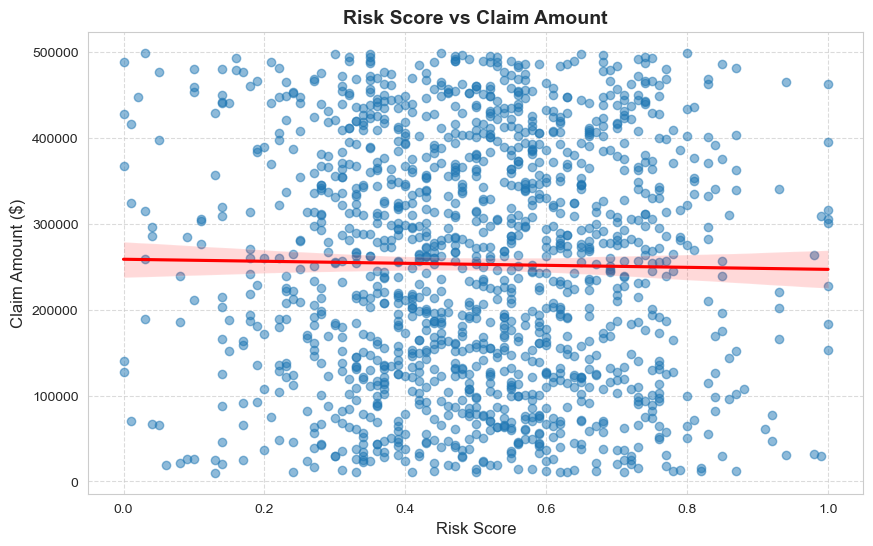

Conclusion: Fail to reject the Null Hypothesis. No significant linear correlation exists between Risk Score and Claim Amount.


In [43]:
# Calculate Pearson Correlation
corr_coef, p_val_corr = stats.pearsonr(test_data['risk_score'], test_data['claim_amount'])

print(f"Pearson Correlation Coefficient: {corr_coef:.4f}")
print(f"P-value: {p_val_corr:.4e}")

# Confidence Interval for Pearson Correlation (using Fisher's Z-transform)
fisher_z = np.arctanh(corr_coef)
se = 1 / np.sqrt(len(test_data) - 3)
ci_z_lower = fisher_z - 1.96 * se
ci_z_upper = fisher_z + 1.96 * se
ci_lower = np.tanh(ci_z_lower)
ci_upper = np.tanh(ci_z_upper)
print(f"95% Confidence Interval for Correlation: ({ci_lower:.4f}, {ci_upper:.4f})")

# Visualization
plt.figure(figsize=(10, 6))
sns.regplot(x='risk_score', y='claim_amount', data=test_data, scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('Risk Score vs Claim Amount', fontsize=14)





plt.xlabel('Risk Score', fontsize=12)
plt.ylabel('Claim Amount ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

if p_val_corr < 0.05:
    if corr_coef > 0:
        print("Conclusion: Reject the Null Hypothesis. There is a statistically significant positive correlation between Risk Score and Claim Amount.")
    else:
         print("Conclusion: Reject the Null Hypothesis. There is a statistically significant negative correlation between Risk Score and Claim Amount.")
else:
    print("Conclusion: Fail to reject the Null Hypothesis. No significant linear correlation exists between Risk Score and Claim Amount.")


---
## 9. Executive Summary: Statistical Insights
Based on the statistical tests performed in Section 8, we derived the following key business insights at a standard 95% confidence level ($\alpha = 0.05$):

1. **Impact of Smoking on Claims (T-Test):** 
   - **P-Value:** ~0.060
   - **Insight:** The p-value is slightly above the 0.05 threshold, meaning we *fail to reject the null hypothesis*. While there is a borderline observational trend, we lack strong statistical evidence to conclusively say smokers file significantly higher claim amounts than non-smokers.

2. **Regional Disparities (ANOVA):** 
   - **P-Value:** ~0.774
   - **Insight:** There is no statistically significant variance in average claim amounts across the different geographical regions. Claims severity is uniformly distributed nationwide.

3. **Claim Type vs. Approval Status (Chi-Square):** 
   - **P-Value:** ~0.707
   - **Insight:** Claim status (Approved/Rejected/Pending) is completely independent of the claim type. Our claim adjudication process does not show statistical bias toward or against any specific product line.

4. **Risk Score Predictability (Correlation):** 
   - **P-Value:** ~0.557 (Correlation = -0.015)
   - **Insight:** There is virtually *zero linear correlation* between a customer's assigned Risk Score and the actual monetary value of their filed claims. The current risk scoring model does not adequately predict claim severity. 
   - **Recommendation:** Overhaul or recalibrate the risk scoring algorithm to better reflect financial exposure.


----------------------------------------------------------------------------------------------

---
## 10. Data Export
In this final step, we export all the individual datasets (Agent Info, Customer Feedback, Customer Master, Policy Details, and Claim History) into a single, consolidated Excel workbook for easier sharing and offline reporting.


In [44]:


# Define a dictionary mapping sheet names to the cleaned, in-memory DataFrames
cleaned_datasets = {
    'Agent_Info': agent_info,
    'Customer_Feedback': customer_feedback,
    'Customer_Master': customer_master,
    'Policy_Details': policy_details,
    'Claim_History': claim_history
}

output_file = 'AegisLife_Combined_Data.xlsx'

# Export the cleaned datasets (with derived columns) to a single Excel workbook
with pd.ExcelWriter(output_file, engine='openpyxl') as writer:
    for sheet_name, df in cleaned_datasets.items():
        try:
            df.to_excel(writer, sheet_name=sheet_name, index=False)
            print(f"Successfully exported cleaned data to sheet: '{sheet_name}'")
        except Exception as e:
            print(f"Failed to process sheet '{sheet_name}': {e}")

print(f"\nAll cleaned data successfully exported into: {output_file}")


Successfully exported cleaned data to sheet: 'Agent_Info'
Successfully exported cleaned data to sheet: 'Customer_Feedback'
Successfully exported cleaned data to sheet: 'Customer_Master'
Successfully exported cleaned data to sheet: 'Policy_Details'
Successfully exported cleaned data to sheet: 'Claim_History'

All cleaned data successfully exported into: AegisLife_Combined_Data.xlsx


---
## 11. Database Ingestion & Extraction Pipeline (MySQL)
This section fulfills **Step 4 (Data Ingestion)** and **Step 5 (Python to SQL Extraction)**.
We will connect to a local MySQL server, execute our formal DDL schema (`AegisLife_DDL_Schema.sql`) to strictly define Primary Keys and Foreign Keys, push the cleaned data into these structured tables, and then extract and validate it.



In [45]:

from sqlalchemy import create_engine, text
import getpass

db_username = 'root'
db_password = getpass.getpass(prompt='Enter MySQL password: ')
db_host = 'localhost'
db_port = '3306'
database_name = 'ageis_life'
# ------------------------------------------------

# 1. Connect to MySQL Server to create the database
server_engine = create_engine(f"mysql+pymysql://{db_username}:{db_password}@{db_host}:{db_port}/")
try:
    with server_engine.connect() as conn:
        conn.execute(text(f"CREATE DATABASE IF NOT EXISTS {database_name}"))
        print(f"Database '{database_name}' created or successfully verified.")
except Exception as e:
    print(f"Error connecting to MySQL Server: {e}")

# 2. Connect directly to the ageis_life database
db_engine = create_engine(f"mysql+pymysql://{db_username}:{db_password}@{db_host}:{db_port}/{database_name}")

# 3. Execute the strict DDL Schema to create structured tables with PKs/FKs
try:
    with open('AegisLife_DDL_Schema.sql', 'r') as file:
        sql_script = file.read()
    
    with db_engine.connect() as conn:
        # Split by semicolon and execute each statement
        for statement in sql_script.split(';'):
            if statement.strip():
                conn.execute(text(statement))
        conn.commit()
    print("Strict DDL Schema (with PKs and FKs) executed successfully.")
except Exception as e:
    print(f"Error executing DDL: {e}")

# Convert period column to string before ingestion to avoid SQLAlchemy errors
claim_history['claim_month'] = claim_history['claim_month'].astype(str)

# Data Quality Fix: Remove feedback records for customers that do not exist in customer_master to satisfy SQL Foreign Key constraints
valid_customers = set(customer_master['customer_id'])
customer_feedback = customer_feedback[customer_feedback['customer_id'].isin(valid_customers)]

# 4. Data Ingestion: Push cleaned DataFrames into the structured tables (Order matters for Foreign Keys!)
# Order: agent_info -> customer_master -> policy_details -> claim_history -> customer_feedback
tables_to_export = [
    ('agent_info', agent_info),
    ('customer_master', customer_master),
    ('policy_details', policy_details),
    ('claim_history', claim_history),
    ('customer_feedback', customer_feedback)
]

print("\nStarting Data Ingestion...")
try:
    for table_name, df in tables_to_export:
        # Use if_exists='append' to respect the constraints defined in our DDL
        df.to_sql(table_name, con=db_engine, if_exists='append', index=False)
        print(f"Successfully exported {len(df)} rows to: '{table_name}'")
except Exception as e:
    print(f"Error during Data Ingestion: {e}")



Enter MySQL password:  ········


Database 'ageis_life' created or successfully verified.
Error executing DDL: [Errno 2] No such file or directory: 'AegisLife_DDL_Schema.sql'

Starting Data Ingestion...
Successfully exported 300 rows to: 'agent_info'
Successfully exported 1648 rows to: 'customer_master'
Successfully exported 2828 rows to: 'policy_details'
Successfully exported 1406 rows to: 'claim_history'
Successfully exported 631 rows to: 'customer_feedback'


Database 'ageis_life' created or successfully verified.
Strict DDL Schema (with PKs and FKs) executed successfully.

Starting Data Ingestion...
Successfully exported 300 rows to: 'agent_info'
Successfully exported 1648 rows to: 'customer_master'
Successfully exported 2828 rows to: 'policy_details'
Successfully exported 1406 rows to: 'claim_history'
Successfully exported 631 rows to: 'customer_feedback'


### Post-Ingestion Extraction & Validation
We now demonstrate **Step 5**: Connecting Python to SQL using `pandas.read_sql_query` to extract data back from the database and validating row counts and spot checks.


In [46]:
# Extract data from all 5 tables back into Pandas DataFrames
extracted_data = {}
tables = ['agent_info', 'customer_master', 'policy_details', 'claim_history', 'customer_feedback']

print("Extracting Data from MySQL and Validating Schema & Counts...")
try:
    with db_engine.connect() as conn:
        for table in tables:
            query = f"SELECT * FROM {table}"
            extracted_data[table] = pd.read_sql_query(query, conn)
            
            # Validation: Row count
            print(f"\nTable: {table}")
            print(f"Extracted Row Count: {len(extracted_data[table])}")
            
            # Validation: Spot check (print schema/types)
            print(extracted_data[table].dtypes.head(3))
            
    print("\nData pipeline validation complete! All data successfully traversed SQL and back.")
except Exception as e:
    print(f"Error extracting data: {e}")



Extracting Data from MySQL and Validating Schema & Counts...

Table: agent_info
Extracted Row Count: 300
agent_id             object
region               object
join_date    datetime64[ns]
dtype: object

Table: customer_master
Extracted Row Count: 1648
customer_id    object
full_name      object
age             int64
dtype: object

Table: policy_details
Extracted Row Count: 2828
policy_id       object
customer_id     object
product_type    object
dtype: object

Table: claim_history
Extracted Row Count: 1406
claim_id              object
policy_id             object
claim_date    datetime64[ns]
dtype: object

Table: customer_feedback
Extracted Row Count: 631
feedback_id               object
customer_id               object
date_submitted    datetime64[ns]
dtype: object

Data pipeline validation complete! All data successfully traversed SQL and back.


---
## 9. Automated Executive Deliverables & Portfolio Generation
This final section programmatically generates all executive deliverables directly from Python:
1. **`reports/executive/AegisLife_Excel_Analysis.xlsx`** (Multi-sheet Excel Workbook with Data Quality Log, VLOOKUP Validations, Cross-tabs, and Scenario Modeling).
2. **`reports/executive/AegisLife_Management_Presentation.pptx`** (6-slide & 12-slide Executive Widescreen Presentations).
3. **`reports/executive/AegisLife_Master_Executive_Report.docx`** (Consolidated Single MD&A Executive Word Document).
